In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [2]:
# Load the dataset
data = pd.read_csv("data/Tesla_Stock.csv")
print(data.head())

   Unnamed: 0        Date       Open       High        Low      Close  \
0           0  02-01-2015  14.858000  14.883333  14.217333  14.620667   
1           1  05-01-2015  14.303333  14.433333  13.810667  14.006000   
2           2  06-01-2015  14.004000  14.280000  13.614000  14.085333   
3           3  07-01-2015  14.223333  14.318667  13.985333  14.063333   
4           4  08-01-2015  14.187333  14.253333  14.000667  14.041333   

     Volume  
0  71466000  
1  80527500  
2  93928500  
3  44526000  
4  51637500  


In [3]:
data.shape 

(2274, 7)

In [4]:
data.describe()

,Unnamed: 0,Open,High,Low,Close,Volume
count,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2.274000e+03
mean,1136.500000,103.493730,105.771617,101.036327,103.461794,1.142089e+08
std,656.591578,111.136174,113.606095,108.399966,111.032019,7.688430e+07
min,0.000000,9.488000,10.331333,9.403333,9.578000,1.062000e+07
25%,568.250000,16.669833,16.933332,16.468833,16.693666,6.637762e+07
50%,1136.500000,23.221334,23.554000,22.842334,23.197333,9.359855e+07
75%,1704.750000,215.272503,219.629173,208.983334,215.227497,1.338214e+08
max,2273.000000,411.470001,414.496674,405.666656,409.970001,9.140820e+08


In [5]:
data.isnull().sum()

Unnamed: 0    0
Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
dtype: int64

In [6]:
data.dtypes

Unnamed: 0      int64
Date              str
Open          float64
High          float64
Low           float64
Close         float64
Volume          int64
dtype: object

In [7]:
data.memory_usage()

Index           132
Unnamed: 0    18192
Date          18192
Open          18192
High          18192
Low           18192
Close         18192
Volume        18192
dtype: int64

In [9]:
X = data[['Open','High','Low','Volume']]
y = data['Close']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
predictions = model.predict(X_test)

print(predictions[:10])

[178.26969736  31.06457273  19.28884473  14.99108954  23.74210625
  51.72016815  17.08813371  13.59077094  14.43298619  17.19099768]


In [13]:
mse = mean_squared_error(
    y_test,
    predictions
)

print("MSE:", mse)

MSE: 4.299213996510319


In [14]:
r2 = r2_score(
    y_test,
    predictions
)

print("R2 Score:", r2)

R2 Score: 0.9996289001990802


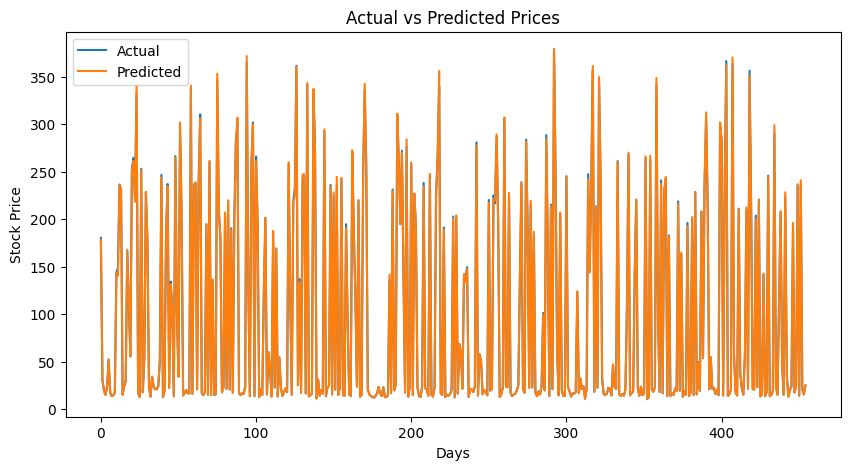

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.title("Actual vs Predicted Prices")

plt.legend()

plt.show()